# Classical

In [186]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.utils import resample
from scipy.linalg import hadamard
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot as plt
%matplotlib inline
from IPython.display import clear_output
import pandas as pd
pd.set_option('display.max_columns', None)
import seaborn as sns
import numpy as np
import random
import prince
from typing import TypeAlias, Union, List
from ucimlrepo import fetch_ucirepo

from numpy.typing import ArrayLike
MatrixLike: TypeAlias = Union[
    ArrayLike,
    pd.DataFrame
]

In [187]:
train = pd.read_csv('lab1-train-processed.csv')
test = pd.read_csv('lab1-test-processed.csv')

display(train)
display(test)

y_train = train['class']
y_test = test['class']
X_train = train.drop('class', axis=1)
X_test = test.drop('class', axis=1)

top_cols = [col for col in X_train.columns if col.startswith('X')]
famd_cols = [col for col in X_train.columns if col.startswith('C')]

,class,X2,C0,X6,C1,X10,C2,X17,C3,X3,C4,X4,C5,X7,C6,X5_1,C7,X13,C8,X15_1,C9
0,6,133.907314,-1.468208,2.989235,0.276903,1.745602,-1.991880,18.008365,1.665992,3.000000,0.229429,0.625350,0.430481,2.923792,-0.388358,0,-0.027717,1.536555,0.191164,0,0.392011
1,4,82.365608,0.714526,1.810804,-0.618230,1.608400,-1.650259,22.339190,-1.390567,1.000000,0.296710,2.000000,1.706740,2.598632,1.324411,0,-0.891510,0.292093,0.010644,0,0.161591
2,5,121.134488,-2.238483,2.811050,0.281797,1.867410,-0.672576,23.274485,0.569318,2.657720,0.563710,0.000000,-0.540056,2.104696,-0.125796,1,0.702596,0.870056,-0.008144,0,-0.410528
3,3,79.125521,0.405247,2.000000,1.650545,1.800000,-0.510070,17.652645,-1.338986,1.000000,1.324808,1.000000,-0.165750,2.000000,0.540286,1,0.183907,2.000000,-0.076974,1,-0.326369
4,5,118.193323,-2.002027,2.191108,0.604417,1.788586,-0.415796,24.566325,0.107035,2.993856,0.729268,0.145284,-0.443735,2.444917,-0.272059,1,0.404912,1.388962,-0.046416,0,-0.086728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1683,3,66.859042,1.451516,2.000000,0.303109,1.640000,0.447478,21.226280,-1.254997,3.000000,-1.246056,1.000000,-0.086139,1.000000,-0.521961,1,-0.363859,0.000000,-0.504150,0,-1.602967
1684,4,98.739188,-0.881631,2.000000,1.897943,1.732694,-0.426703,21.494374,-1.222413,2.993623,-0.707082,1.529423,0.645786,2.326635,-0.720979,1,-1.006865,2.236586,0.317045,0,-0.150458
1685,4,95.973811,-1.011257,2.000000,2.155115,1.741353,-0.333581,21.005434,-0.944677,3.000000,-0.354342,1.229474,0.727815,2.697661,-1.109787,1,-0.995599,2.614909,0.431379,0,-0.052324
1686,0,79.634810,-1.090697,1.993101,0.495533,1.745950,-0.022242,24.969213,-0.348468,3.171082,0.713230,0.022245,-0.693482,2.364498,-0.282761,1,0.378846,1.224743,-0.208985,0,0.082620


,class,X2,C0,X6,C1,X10,C2,X17,C3,X3,C4,X4,C5,X7,C6,X5_1,C7,X13,C8,X15_1,C9
0,0,65.517027,0.484487,2.374640,-1.847356,1.449559,1.590055,36.591143,0.396030,3.000000,-0.189425,0.480813,0.340385,2.000000,-1.107690,0,-0.227402,2.892922,0.179947,0,1.047396
1,4,80.321076,0.109128,2.766320,-3.276887,1.582523,2.075080,42.412773,-0.221815,1.317884,-0.121852,0.000000,1.570310,1.967408,-1.178837,0,-0.372068,0.990642,0.527927,0,-0.123479
2,6,103.939346,0.073094,3.000000,-1.897598,1.617390,-1.372753,24.228630,0.688670,3.000000,-0.626943,0.541309,-0.320001,1.292479,0.558842,0,0.421557,0.000000,-0.395995,0,-0.056059
3,3,64.881769,-0.796613,3.000000,1.193776,1.780000,1.134938,24.192968,0.908599,3.000000,-0.281191,1.000000,0.873024,2.000000,2.358295,1,-2.152621,1.000000,0.820595,0,2.345712
4,4,103.919796,-1.670365,2.253707,0.339208,1.785718,-0.616425,23.199143,-0.033524,3.000000,0.776164,0.175694,-0.464756,2.524432,0.078508,1,0.435049,0.582160,-0.180257,0,0.012671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,6,106.455606,-0.521648,3.009608,-1.567272,1.629191,-1.414409,27.070496,1.220609,3.000000,0.150220,0.555468,0.401723,2.654702,0.222386,0,0.132335,0.000000,-0.099324,0,0.446954
419,3,60.350897,0.979537,2.000000,0.074900,1.650000,0.661700,22.742513,-0.687676,3.000000,-0.106647,0.000000,0.040351,2.000000,-1.063919,1,-0.124470,0.000000,-0.350357,0,-1.211942
420,4,95.104136,-0.641643,2.000000,1.167839,1.701986,-0.225637,22.698244,-1.236276,3.000000,-0.591072,1.066603,0.349936,2.021270,-0.624453,1,-0.686549,1.814869,0.152797,0,-0.284635
421,4,80.293832,0.202996,2.000000,-3.692421,1.529060,1.813763,40.067806,-0.553698,3.000000,-0.338952,0.000000,-0.623399,1.000000,0.189557,0,0.530507,0.000000,-0.555358,0,0.418316


In [188]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[X_train.columns])
X_test_scaled = scaler.transform(X_test[X_test.columns])

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.38      0.45        58
           1       0.52      0.50      0.51        58
           2       0.78      0.98      0.87        54
           3       0.48      0.45      0.46        58
           4       0.74      0.60      0.66        70
           5       0.72      0.97      0.83        60
           6       0.94      1.00      0.97        65

    accuracy                           0.70       423
   macro avg       0.68      0.70      0.68       423
weighted avg       0.68      0.70      0.68       423



In [189]:
svc = SVC(kernel='rbf', class_weight='balanced')
svc.fit(X_train_scaled, y_train)
y_pred = svc.predict(X_test_scaled)
print("SVC Classification Report:")
print(classification_report(y_test, y_pred))

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.53      0.57        58
           1       0.68      0.76      0.72        58
           2       0.81      0.96      0.88        54
           3       0.62      0.64      0.63        58
           4       0.94      0.69      0.79        70
           5       0.85      0.97      0.91        60
           6       1.00      1.00      1.00        65

    accuracy                           0.79       423
   macro avg       0.79      0.79      0.79       423
weighted avg       0.80      0.79      0.79       423



In [190]:
def build_ecoc_matrix(n_classes: int, ensemble_size: int) -> np.ndarray:
    n = 2 ** int(np.ceil(np.log2(ensemble_size)) + 1)

    H = hadamard(n)[:n_classes]

    code = ((H + 1) // 2).astype(int)

    mask = (code.sum(0) > 0) & (code.sum(0) < n_classes)
    code = code[:, mask]

    return np.array(code[:, :ensemble_size]).T

In [191]:
ecoc = build_ecoc_matrix(7, 14)

final_preds = np.array([[0, 0, 0, 0, 0, 0, 0] for _ in range(len(y_test))])
for i, code in enumerate(ecoc):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(X_train_scaled, y_train.apply(lambda x: code[x]))
    y_pred = clf.predict(X_test_scaled)

    # # Individual classification report for each binary classifier
    # print(f"Classifier {i+1} (Code: {code}):")
    # print(classification_report(y_test.apply(lambda x: code[x]), y_pred))

    for j, pred in enumerate(y_pred):
        final_preds[j][code == pred] += 1

final_preds = np.argmax(final_preds, axis=1)
print("Logistic Regression Ensemble Classification Report:")
print(classification_report(y_test, final_preds))

Logistic Regression Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.59      0.43        58
           1       0.34      0.33      0.33        58
           2       0.56      0.81      0.67        54
           3       0.35      0.14      0.20        58
           4       0.72      0.37      0.49        70
           5       0.64      0.62      0.63        60
           6       0.90      1.00      0.95        65

    accuracy                           0.55       423
   macro avg       0.55      0.55      0.53       423
weighted avg       0.56      0.55      0.53       423



In [192]:
ecoc = build_ecoc_matrix(7, 14)

final_preds = np.array([[0, 0, 0, 0, 0, 0, 0] for _ in range(len(y_test))])
for i, code in enumerate(ecoc):
    clf = SVC(kernel='rbf', class_weight='balanced')
    clf.fit(X_train_scaled, y_train.apply(lambda x: code[x]))
    y_pred = clf.predict(X_test_scaled)

    # # Individual classification report for each binary classifier
    # print(f"Classifier {i+1} (Code: {code}):")
    # print(classification_report(y_test.apply(lambda x: code[x]), y_pred))

    for j, pred in enumerate(y_pred):
        final_preds[j][code == pred] += 1

final_preds = np.argmax(final_preds, axis=1)
print("SVC Ensemble Classification Report:")
print(classification_report(y_test, final_preds))

SVC Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.59      0.54        58
           1       0.57      0.67      0.61        58
           2       0.85      0.94      0.89        54
           3       0.55      0.38      0.45        58
           4       0.85      0.64      0.73        70
           5       0.84      0.97      0.90        60
           6       1.00      1.00      1.00        65

    accuracy                           0.74       423
   macro avg       0.74      0.74      0.73       423
weighted avg       0.74      0.74      0.74       423



# Quantum

In [193]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import AngleEmbedding, IQPEmbedding, StronglyEntanglingLayers, BasicEntanglerLayers
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

import time
import copy
from typing import Literal

plt.rcParams["figure.figsize"] = (12, 6)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = "cpu"

print(f"Using device: {DEVICE}\n")
qml.about()

Using device: cpu

Name: pennylane
Version: 0.45.0
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: /home/edwar/.pyenv/versions/3.14.5/lib/python3.14/site-packages
Platform info:           Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
Python version:          3.14.5
Numpy version:           2.4.6
Scipy version:           1.17.1
JAX version:             None
Catalyst version:        None
Installed devices:
- lightning.gpu (pennylane_lightning_gpu-0.45.0)
- default.clifford (pennylane-0.45.0)
- default.gaussian (pennylane-0.45.0)
- default.mixed (pennylane-0.45.0)
- default.qubit (pennylane-0.45.0)
- default.qutrit (pennylane-0.45.0)
- default.qutrit.mixed (pennylane-0.45.0)
- default.tensor (pennylane-0.45.0)
- null.qubit (pennylane-0.45.0)
- reference.qubit (pennylane-0.45.0)
- lightning.qubit (pe

In [194]:
n_qubits = 2
n_layers = 2

if DEVICE == "cuda":
    dev = qml.device("lightning.gpu", wires=n_qubits)
else:
    dev = qml.device("default.qubit", wires=n_qubits)
    
scaler = MinMaxScaler(feature_range=(0, np.pi))

(<Figure size 500x300 with 1 Axes>, <Axes: >)
<default.qubit device (wires=2) at 0x7495b5c74f30>
best


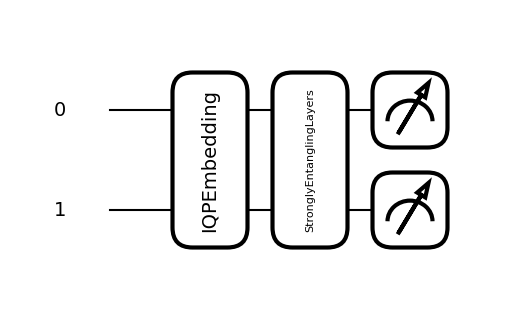

In [195]:
@qml.qnode(dev, interface='torch', diff_method='best')
def circuit(inputs: torch.Tensor, weights: torch.Tensor) -> qml.measurements.ProbabilityMP:
    IQPEmbedding(inputs, wires=range(n_qubits), n_repeats=2)
    StronglyEntanglingLayers(weights, wires=range(n_qubits))

    return qml.probs(wires=[0, 1])

weight_shapes = {
    "weights": (n_layers, n_qubits, 3)
}

print(qml.draw_mpl(circuit)(np.zeros(n_qubits), np.zeros(weight_shapes["weights"])))
print(circuit.device)
print(circuit.diff_method)

In [196]:
qlayer = qml.qnn.TorchLayer(circuit, weight_shapes=weight_shapes)

In [197]:
class VQC(nn.Module):
    def __init__(self, qlayer: qml.qnn.TorchLayer):
        super().__init__()
        self.qlayer = qlayer
  
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        probs = self.qlayer(x)
        p00, p01, p10, p11 = probs[:, 0], probs[:, 1], probs[:, 2], probs[:, 3]

        return torch.stack([p00 + p11, p01 + p10], dim=1)
    
    def fit(
        self,
        train_loader: torch.utils.data.DataLoader,
        test_loader: torch.utils.data.DataLoader = None,
        epochs: int = 100,
        lr: float = 0.01,
        optimizer_cls: torch.optim.Optimizer = torch.optim.Adam,
        criterion: nn.Module = nn.NLLLoss(),
        patience: int = 5,
        warmup: int = 15,
        min_delta: float = 1e-3,
        plot: bool = True,
        restore_best: bool = True,
        verbose: bool = True,
    ):
        self.to(DEVICE)

        optimizer = optimizer_cls(self.parameters(), lr=lr)

        best_state = None
        patience_counter = 0

        train_losses = []
        val_losses = []
        best_loss = float("inf")

        time_start = time.time()
        for epoch in range(epochs):
            # Training
            epoch_loss = 0.0
            self.train()
            for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
                if verbose:
                    print(f"[Epoch {epoch + 1}/{epochs}] Batch {batch_idx + 1}/{len(train_loader)}", end="\r")

                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                optimizer.zero_grad()

                probs = self(X_batch)
                loss = criterion(probs, y_batch)

                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            avg_train_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_train_loss)

            # Validation
            if test_loader:
                val_loss = 0.0
                correct = 0
                total = 0
                self.eval()
                with torch.no_grad():
                    for X_batch, y_batch in test_loader:
                        X_batch = X_batch.to(DEVICE)
                        y_batch = y_batch.to(DEVICE)

                        probs = self(X_batch)
                        loss = criterion(probs, y_batch)

                        val_loss += loss.item()

                        preds = probs.argmax(dim=1)
                        correct += (preds == y_batch).sum().item()
                        total += y_batch.size(0)

                avg_val_loss = val_loss / len(test_loader)
                val_acc = correct / total

                val_losses.append(avg_val_loss)

            # Plot
            if plot:
                clear_output(wait=True)
                plt.figure(figsize=(10, 6))
                plt.plot(train_losses, label="Train Loss")
                if test_loader:
                    plt.plot(val_losses, label="Validation Loss")
                plt.xlabel("Epoch")
                plt.ylabel("Loss")
                plt.title(f"Training {'and Validation' if test_loader else ''} Loss")
                plt.legend()
                plt.grid(True)
                plt.xlim(0, max(1, len(train_losses)))
                plt.show()

            if verbose:
                print(f"[Epoch {epoch + 1}/{epochs}] Train Loss: {avg_train_loss:.4f} {f'| Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.3f}' if test_loader else ''}")
            
            # Early stopping
            monitor_loss = avg_val_loss if test_loader else avg_train_loss
            if epoch >= warmup:
                if monitor_loss < best_loss - min_delta:
                    best_loss = monitor_loss
                    patience_counter = 0

                    if restore_best:
                        best_state = copy.deepcopy(self.state_dict())
                else:
                    patience_counter += 1

                if patience_counter >= patience:
                    if verbose:
                        print(f"Early stopping at epoch {epoch + 1}")
                    break
            else:
                if monitor_loss < best_loss:
                    best_loss = monitor_loss

                    if restore_best:
                        best_state = copy.deepcopy(self.state_dict())

        if restore_best and best_state is not None:
            self.load_state_dict(best_state)

        if verbose:
            time_end = time.time()
            print(f"Total training time: {time_end - time_start:.2f} seconds")

        self.train_losses = train_losses
        self.val_losses = val_losses
        self.best_loss = best_loss

    def predict(self, X: torch.Tensor) -> torch.Tensor:
        self.eval()
        with torch.no_grad():
            probs = self(X.to(DEVICE))
            preds = probs.argmax(dim=1)
            return preds.cpu()
    
    def predict_proba(self, X: torch.Tensor) -> torch.Tensor:
        self.eval()
        with torch.no_grad():
            probs = self(X.to(DEVICE))
            return probs.cpu()

    def score(self, X: torch.Tensor, y: torch.Tensor) -> float:
        preds = self.predict(X)
        return accuracy_score(y, preds)

In [198]:
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets
y = np.where(y == 'M', 1, 0).ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

pca = prince.PCA(n_components=2, n_iter=5, random_state=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

X_tr = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32).to(DEVICE)
X_te = torch.tensor(scaler.transform(X_test), dtype=torch.float32).to(DEVICE)
y_tr = torch.tensor(y_train, dtype=torch.long).to(DEVICE)
y_te = torch.tensor(y_test, dtype=torch.long).to(DEVICE)

trainloader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
testloader = DataLoader(TensorDataset(X_te, y_te), batch_size=32, shuffle=False)

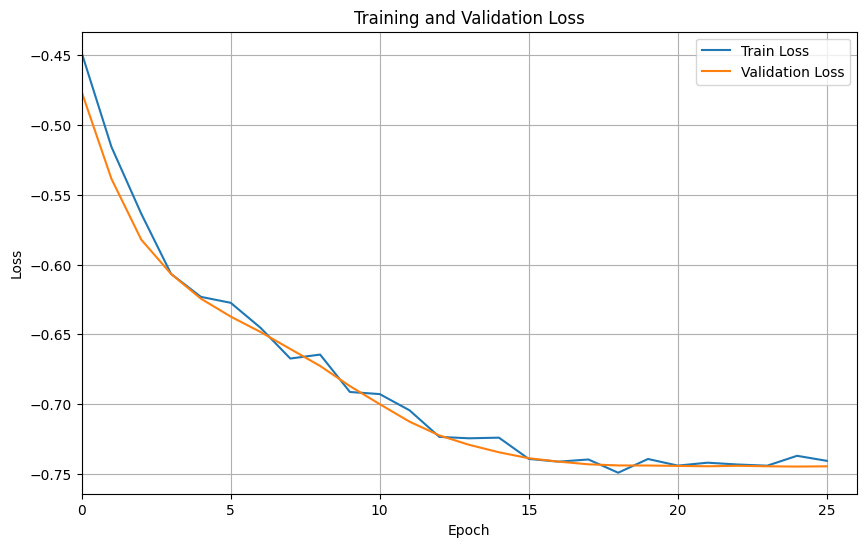

[Epoch 26/100] Train Loss: -0.7407 | Val Loss: -0.7446 | Val Acc: 0.877
Early stopping at epoch 26
Total training time: 4.41 seconds


In [199]:
model = VQC(qlayer)
model.fit(trainloader, testloader)

In [200]:
train_score = model.score(X_tr, y_tr)

print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_te, model.predict(X_te), zero_division=0))

for probs, pred in zip(model.predict_proba(X_te), model.predict(X_te)):
    p0, p1 = probs
    print(f"P(0): {p0:.4f}, P(1): {p1:.4f} | Predicted Class: {pred.item()}")

Training Accuracy: 0.84
Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.89        72
           1       1.00      0.60      0.75        42

    accuracy                           0.85       114
   macro avg       0.90      0.80      0.82       114
weighted avg       0.88      0.85      0.84       114

P(0): 0.7569, P(1): 0.2431 | Predicted Class: 0
P(0): 0.7485, P(1): 0.2515 | Predicted Class: 0
P(0): 0.8878, P(1): 0.1122 | Predicted Class: 0
P(0): 0.8108, P(1): 0.1892 | Predicted Class: 0
P(0): 0.9387, P(1): 0.0613 | Predicted Class: 0
P(0): 0.8634, P(1): 0.1366 | Predicted Class: 0
P(0): 0.8426, P(1): 0.1574 | Predicted Class: 0
P(0): 0.4330, P(1): 0.5670 | Predicted Class: 1
P(0): 0.9258, P(1): 0.0742 | Predicted Class: 0
P(0): 0.7940, P(1): 0.2060 | Predicted Class: 0
P(0): 0.7307, P(1): 0.2693 | Predicted Class: 0
P(0): 0.9341, P(1): 0.0659 | Predicted Class: 0
P(0): 0.7496, P(1): 0.2504 | Predicted Class: 0
P

## Ensemble

In [201]:
class QuECOC:
    def __init__(self, qlayer: qml.qnn.TorchLayer, n_classes: int, ensemble_size: int = 14):
        self.n_classes = n_classes
        self.qlayer = qlayer
        self.ensemble_size = ensemble_size
            
        self.ecoc = build_ecoc_matrix(self.n_classes, self.ensemble_size)
        self.classifiers = []

    def fit(self, X: MatrixLike, y: ArrayLike, **fit_params):
        X_tr = torch.tensor(X, dtype=torch.float32).to(DEVICE)

        for code in self.ecoc:
            y_train = y.apply(lambda x: code[x])
            y_tr = torch.tensor(y_train.values, dtype=torch.bool).to(DEVICE)

            trainloader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

            clf = VQC(n_qubits=2, n_classes=2, qlayer=self.qlayer)
            clf.fit(trainloader, **fit_params)
            self.classifiers.append(clf)

    def predict(self, X: MatrixLike) -> np.ndarray:
        X_tr = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        final_preds = [[0] * self.n_classes] * len(X)
        for i, clf in enumerate(self.classifiers):
            preds = clf.predict(X_tr)

            for j, pred in enumerate(preds):
                final_preds[j][self.ecoc[i] == pred] += 1

        return np.array(final_preds).argmax(axis=1)
    
    def predict_proba(self, X: MatrixLike) -> np.ndarray:
        X_tr = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        final_preds = [[0] * self.n_classes] * len(X)
        for i, clf in enumerate(self.classifiers):
            preds = clf.predict_proba(X_tr)

            for j, pred in enumerate(preds):
                final_preds[j][self.ecoc[i] == 0] += pred[0].item()
                final_preds[j][self.ecoc[i] == 1] += pred[1].item()

        return np.array(final_preds) / self.ensemble_size
    
    def score(self, X, y):
        preds = self.predict(X)
        final_preds = np.argmax(preds, axis=1)
        return accuracy_score(y, final_preds)